In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np


(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

print("Train images shape :", train_images.shape)   # (50000, 32, 32, 3)
print("Train labels shape :", train_labels.shape)   # (50000, 1)
print("Test images shape  :", test_images.shape)    # (10000, 32, 32, 3)
print("Test labels shape  :", test_labels.shape)    # (10000, 1)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train images shape : (50000, 32, 32, 3)
Train labels shape : (50000, 1)
Test images shape  : (10000, 32, 32, 3)
Test labels shape  : (10000, 1)


/tmp/ipykernel_31/253551797.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(class_names[int(train_labels[idx])], fontsize=7)


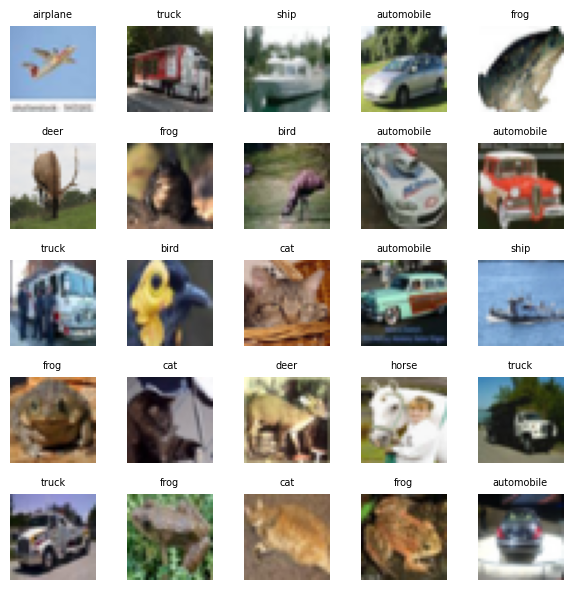

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']



fig, axes = plt.subplots(5, 5, figsize=(6, 6))

idxs = np.random.choice(len(train_images), 25, replace=False)

for ax, idx in zip(axes.flat, idxs):
    ax.imshow(train_images[idx])
    ax.set_title(class_names[int(train_labels[idx])], fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_grid.png', dpi=300)
plt.show()


In [4]:
train_images = train_images.astype("float32") / 255.0
test_images  = test_images.astype("float32")  / 255.0

In [5]:

inputs = Input(shape=(32, 32, 3))

x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)


I0000 00:00:1745868404.745825      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 520,906 (1.99 MB)

 Trainable params: 520,906 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(train_images)

history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=64),
    epochs=30,
    validation_data=(test_images, test_labels)
)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1745868408.936494      96 service.cc:148] XLA service 0x7ec74804e710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745868408.937586      96 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745868409.257210      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


  8/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.1052 - loss: 2.3172

I0000 00:00:1745868411.928598      96 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.2773 - loss: 1.9370 - val_accuracy: 0.5217 - val_loss: 1.3025
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.4965 - loss: 1.3964 - val_accuracy: 0.6259 - val_loss: 1.0598
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5845 - loss: 1.1827 - val_accuracy: 0.6712 - val_loss: 0.9211
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.6342 - loss: 1.0443 - val_accuracy: 0.6936 - val_loss: 0.8803
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6708 - loss: 0.9521 - val_accuracy: 0.7117 - val_loss: 0.8295
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6956 - loss: 0.8934 - val_accuracy: 0.7411 - val_loss: 0.7552
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.7076 - loss: 0.8538 - val_accuracy: 0.7423 - val_loss: 0.7577
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.7200 - loss: 0.8187 - val_accurac

In [9]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")


Test accuracy: 0.807


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step


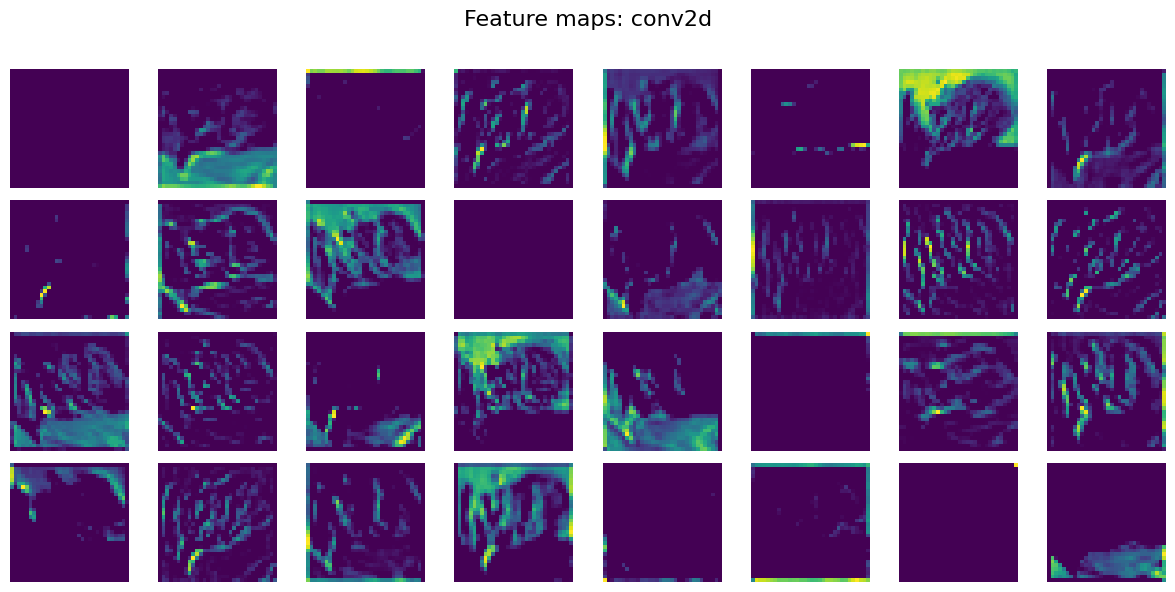

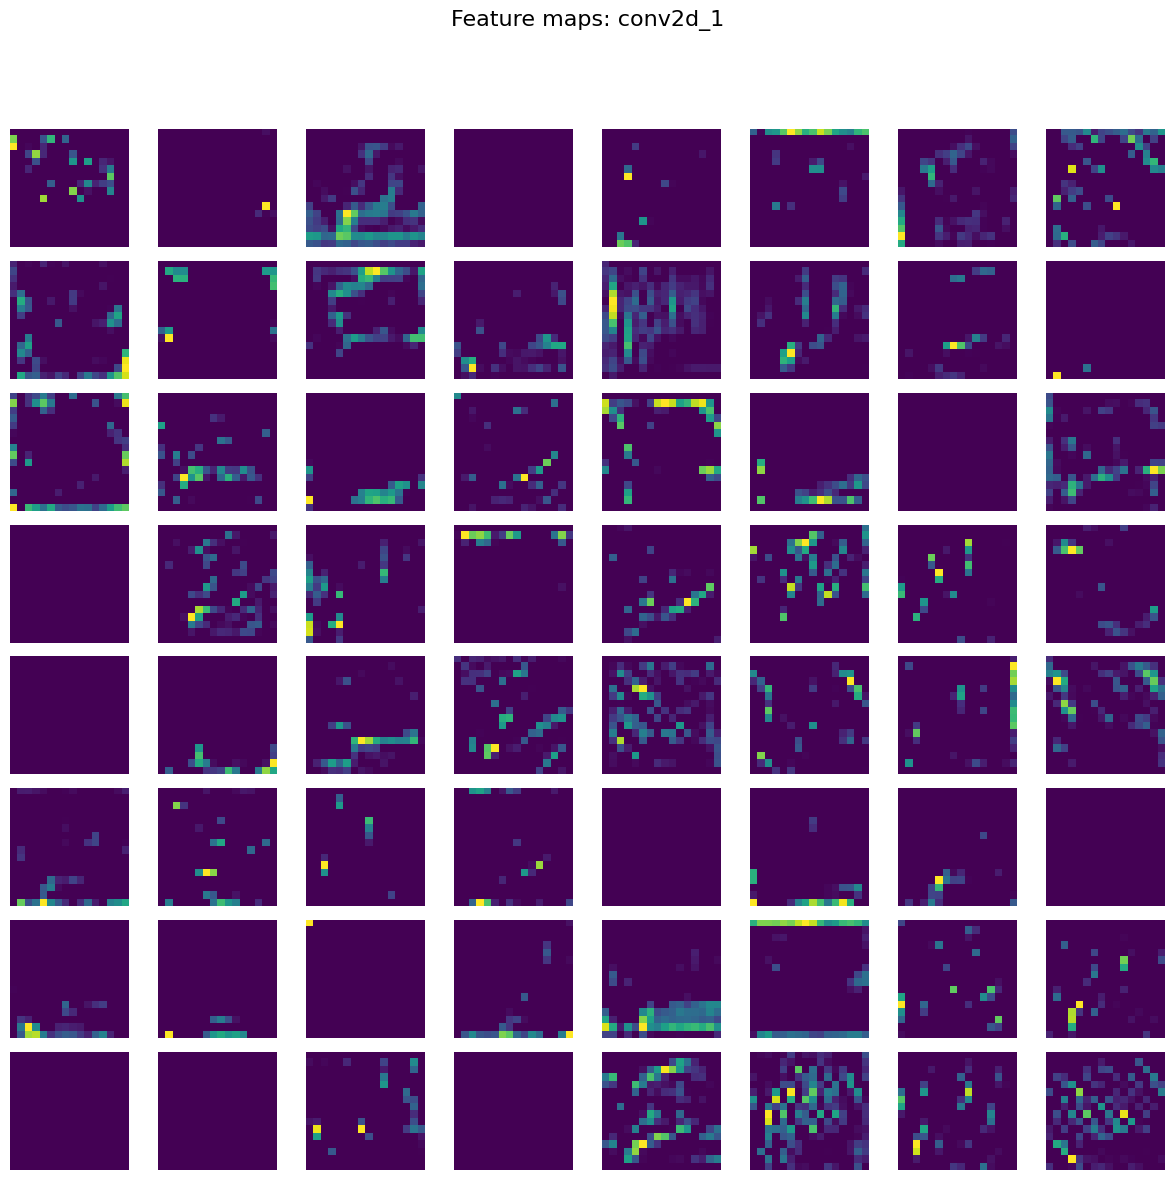

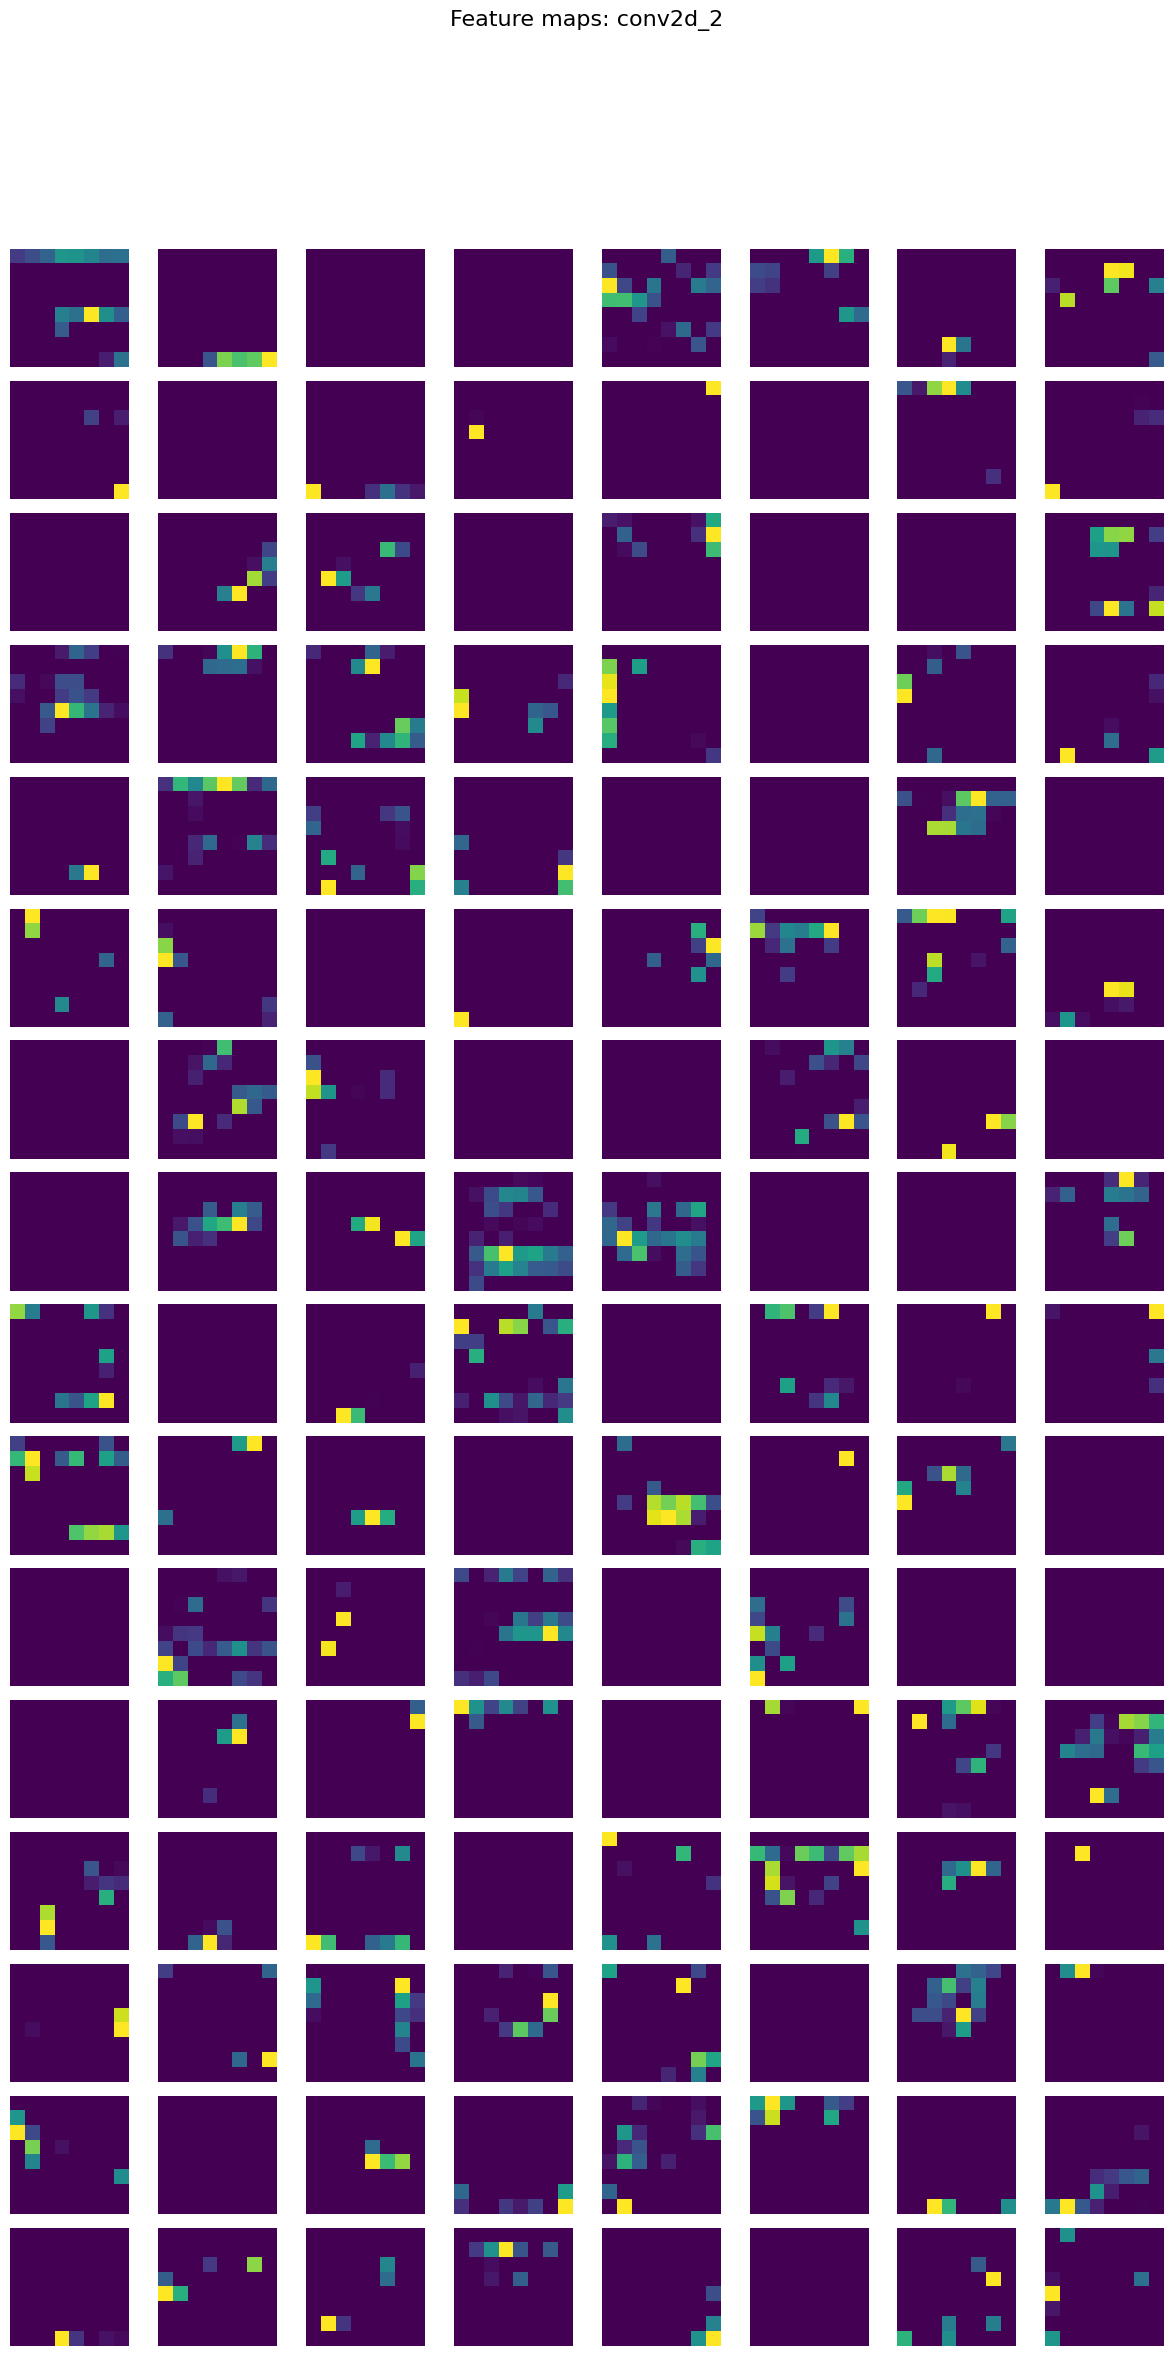

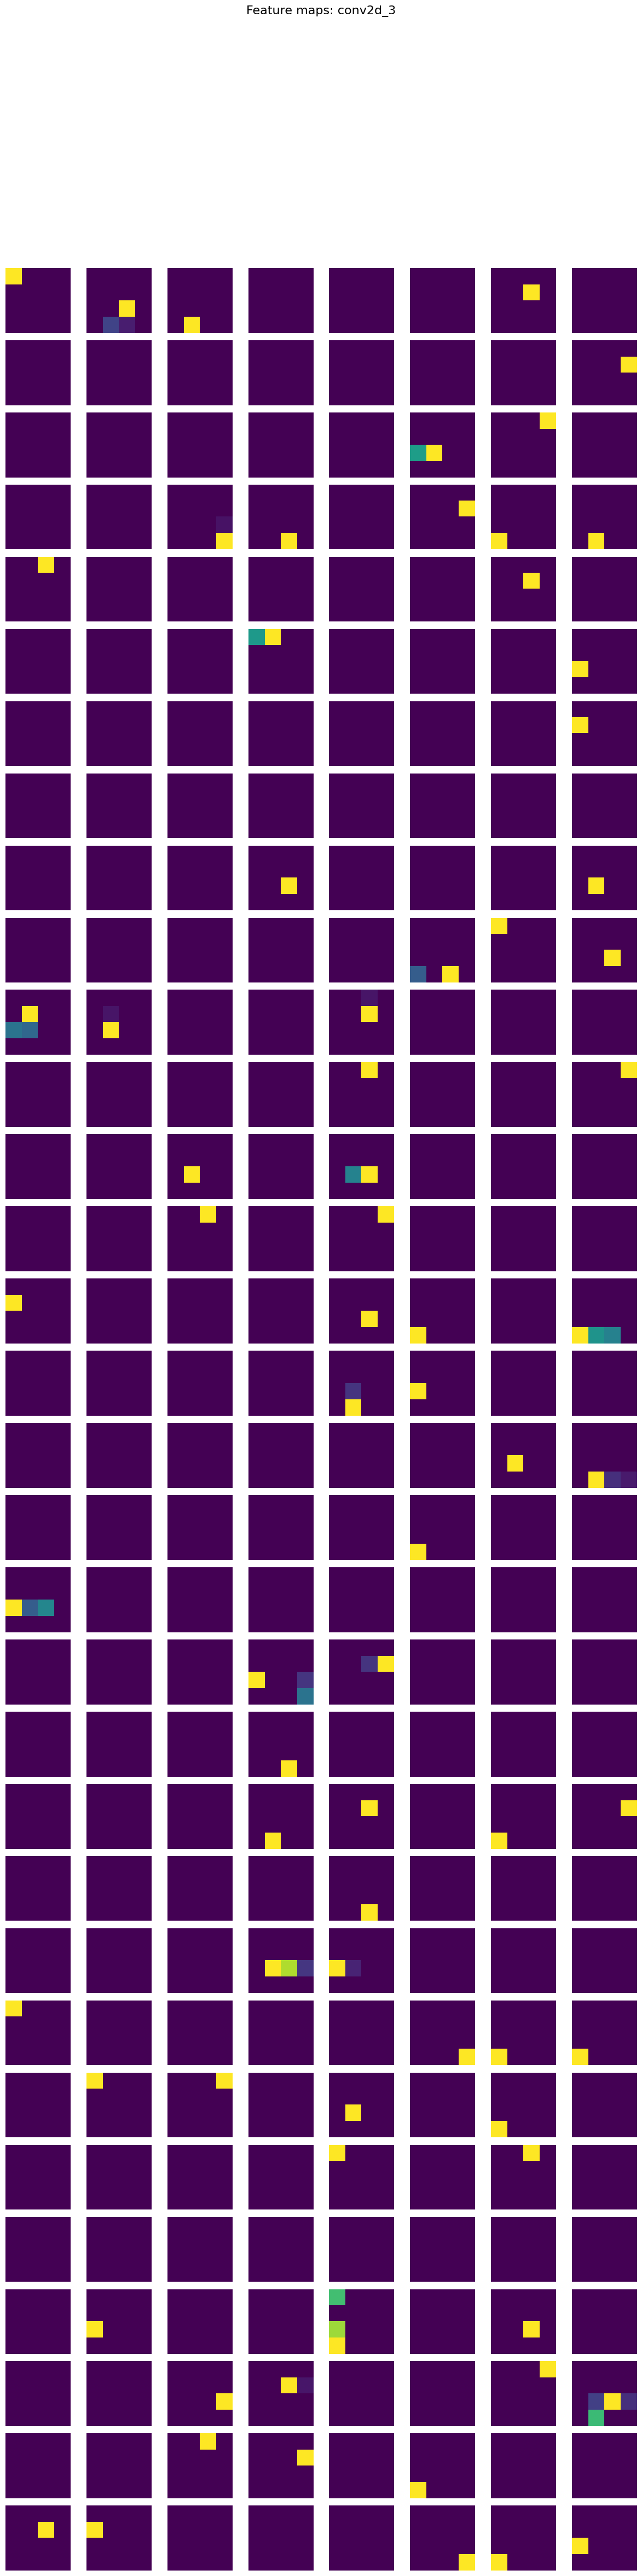

In [12]:
from tensorflow.keras.models import Model

img = test_images[0]
img = img.reshape(1, 32, 32, 3)

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

feature_maps = activation_model.predict(img)

for layer_name, activation in zip([layer.name for layer in model.layers if 'conv' in layer.name], feature_maps):
    n_features = activation.shape[-1]
    size = activation.shape[1]

    cols = 8
    rows = n_features // cols
    if n_features % cols != 0:
        rows += 1

    fig, axes = plt.subplots(rows, cols, figsize=(1.5*cols, 1.5*rows))
    fig.suptitle(f'Feature maps: {layer_name}', fontsize=16)

    for i in range(rows*cols):
        if i < n_features:
            ax = axes[i//cols, i%cols]
            act_map = activation[0, :, :, i]
            ax.imshow(act_map, cmap='viridis')
            ax.axis('off')
        else:
            axes[i//cols, i%cols].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

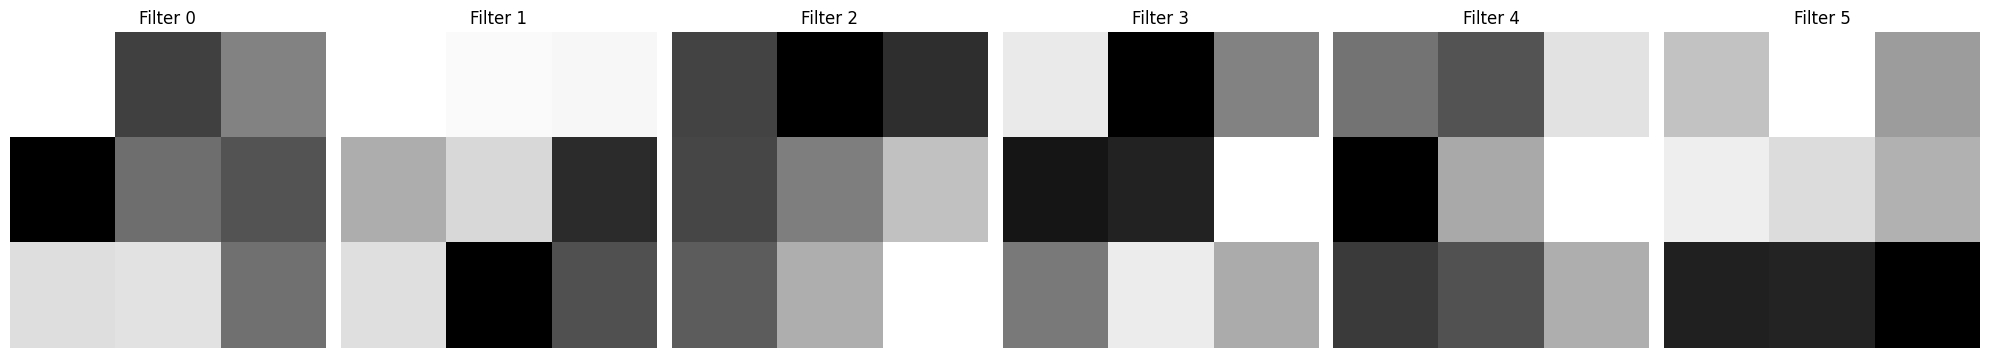

In [13]:
filters, biases = model.layers[1].get_weights()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = min(6, filters.shape[-1])
fig, axs = plt.subplots(1, n_filters, figsize=(20,5))

for i in range(n_filters):
    f = filters[:, :, :, i]
    axs[i].imshow(f[:, :, 0], cmap='gray')
    axs[i].set_title(f'Filter {i}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()


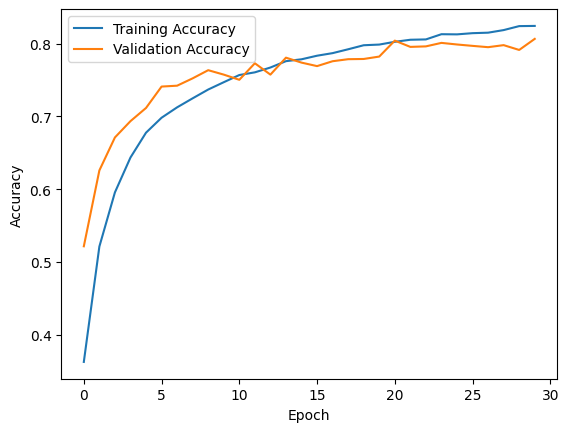

In [17]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [16]:
model.save('my_cifar10_model.h5')